# COMP - 2040: Final Project  
**Name:** Troy Dela Rosa  
**SID#** 0213352  
**Date** April 11, 2026  
**Instructor:** Chris Mac  

## 1. Introduction

### How Instructor Feedback Changed This Project

In weeks 12 and 13 I focused on downtown Winnipeg business license activity from 2023 to 2025. The data came from the City of Winnipeg open-data portal, and the plan was to look at whether license patterns showed a measurable decline.

After the week 13 check-in, Chris pointed out that a three-year window is too narrow to tell whether what I was seeing was a real structural trend or just short-term noise. He suggested pushing the timeline back as far as the data would allow.

That feedback changed the project in a big way. I called 311 and submitted a formal data request through the City's website, but the historical license records I was hoping for were not available in time. Instead I expanded the analysis by building and collecting additional datasets from public sources — CBRE vacancy reports, Downtown BIZ snapshots, StatCan census data, and local news reporting — to piece together a longer-term picture stretching back to 2010.

The result is a project that no longer just asks *"is downtown declining?"* but instead tries to understand *how, when, and in what way* downtown Winnipeg has been changing — and whether the $2.3 billion in tracked investment represents recovery, or something structurally different.

### Central Argument

Downtown Winnipeg is not recovering in the traditional sense. It is converting from a retail-and-office-anchored model to a residential and institutional one. The investment does not attempt to restore what was lost — it bets on a different urban form.

### Three Analytical Questions

1. **How has the balance of Growth vs. Transition events shifted across the three phases of downtown development?**
2. **Has downtown business activity declined — and which sectors were hit hardest?**
3. **Can we predict the delivery status of a housing project (Completed / Under Construction / Planned) based on its characteristics?**|


> *This analysis uses exploratory data analysis and visualization to examine development activity, business activity, and vacancy trends in Downtown Winnipeg. Interpretations are exploratory — not causal claims.*

## 2. Data Sources and Research Design

### What datasets am I working with?

This project uses several datasets I built and collected from public sources:

- **`downtown_wpg_gantt_sourced_2026.csv`** — 28 major structural events in Downtown Winnipeg between 2010 and 2026, including construction projects, retail closures, and policy decisions. Each row records a start date, end date, event category, and a source provenance rating.
- **`housing_pipeline_2026.csv`** — residential development projects in the downtown pipeline, with unit count ranges, delivery status, and confidence levels.
- **`Business_Licenses_20260404.csv`** — City of Winnipeg open data: downtown business license records from 2021 to 2026.
- **`Winnipeg_Synthetic_License_Model_2010_2024.xlsx`** — A calibrated synthetic model that estimates downtown business activity from 2010 to 2020, where official open data is unavailable.
- **`downtown_wpg_sources_2026.csv`** — A source provenance registry documenting every figure with its source, confidence score, and usage type.

### Where does the data come from?

The business license data comes directly from the City of Winnipeg Open Data portal. The structural events and housing pipeline datasets were built by me from public sources: CBRE market reports, Downtown Winnipeg BIZ annual snapshots, and CBC Manitoba news reporting. The full source registry documents 53 sources.

### Data Layer Structure

Each section is labeled so the reader knows how reliable every number is:

| Layer | Label | Meaning |
|---|---|---|
| **L1 — Observed** | `[OBSERVED]` | Directly confirmed from primary sources |
| **L2 — Reconstructed** | `[RECONSTRUCTED]` | Calibrated estimates filling known data gaps |
| **L3 — Inferred** | `[INFERRED]` | Patterns derived from L1/L2, not direct measurements |
| **L4 — Scenario** | `[SCENARIO]` | Model outputs under stated assumptions |

## 3. Setup

In [23]:
# standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# scikit-learn imports for prediction section
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# dark chart style — all charts inherit this
plt.rcParams.update({
    'figure.facecolor': '#0d0f14',
    'axes.facecolor':   '#161921',
    'axes.edgecolor':   '#2a2e3a',
    'axes.labelcolor':  '#e0ddd5',
    'text.color':       '#e0ddd5',
    'xtick.color':      '#8a8780',
    'ytick.color':      '#8a8780',
    'grid.color':       '#2a2e3a',
    'font.family':      'sans-serif',
    'font.size':        11,
    'figure.dpi':       120
})

# colour constants
ACCENT    = '#c9a44a'   # gold
GROWTH_C  = '#4e9a6e'   # green
TRANS_C   = '#5a7bbf'   # blue
DECLINE_C = '#bf4e4e'   # red

PHASE_COLORS = {
    'Pre-2015 establishment':    '#6e8a9e',
    '2015\u20132020 transition': DECLINE_C,
    '2020+ restructuring':       GROWTH_C,
}

TYPE_COLORS = {
    'Growth':         '#4e9a6e',
    'Infrastructure': '#5a7bbf',
    'Transition':     '#bf4e4e',
    'Adaptive Reuse': '#c9a44a',
    'Policy':         '#8a6e9a',
}

print("Ready.")

Ready.


### Helper Module — New Function for Week 14

Weeks 12–13 already had three helper functions in `src/helpers.py`:
- `clean_column_names()` — lowercase + underscore formatting
- `create_is_closed()` — flags closed/cancelled/ceased licenses
- `filter_downtown()` — keeps only downtown Community Characterization Area

For week 14 I added a fourth function that assigns each gantt event to its development phase based on start year. I'm defining it here so the notebook is self-contained, but it also lives in `helpers.py`.

## 4. Data Overview

Before cleaning or analysing anything, I want to understand the basic shape of each dataset — how many rows, what the columns are, and where the missing values are.

In [49]:
import sys
import importlib
import os
import pandas as pd

sys.path.insert(0, '..')

import src.helpers
importlib.reload(src.helpers)

from src.helpers import (
    preview_dataset,
    clean_column_names,
    filter_downtown,
    summarize_business_license_overview,
    summarize_source_registry,
    clean_gantt,
    clean_housing,
    clean_business_licenses,
    prepare_housing_prediction_data,
)

### 4.1 Gantt Sourced Dataset

In [43]:
gantt_raw = pd.read_csv('../data/downtown_wpg_gantt_sourced_2026.csv')

preview_dataset(
    gantt_raw,
    title='GANTT DATASET',
    preview_cols=['task_name', 'category', 'start_date', 'end_date', 'status', 'source_quality'],
    n=3
)

=== GANTT DATASET ===
Shape: (30, 12)

Columns and types:
task_name              object
category               object
type                   object
start_date             object
end_date               object
status                 object
row_type               object
source_quality         object
biz_fallback             bool
primary_source_id      object
secondary_source_id    object
source_note            object

Missing values per column:
task_name               0
category                0
type                    0
start_date              0
end_date               11
status                  0
row_type                0
source_quality          0
biz_fallback            0
primary_source_id       0
secondary_source_id     6
source_note             0

First 3 rows:
                       task_name       category start_date   end_date    status source_quality
 RBC Convention Centre expansion Infrastructure 2013-01-01 2016-03-31 Completed           weak
Canadian Museum for Human Rights Infr

In [44]:
print(gantt_raw['source_quality'].value_counts())
print()
print(gantt_raw['row_type'].value_counts())

source_quality
strong      12
weak         9
moderate     9
Name: count, dtype: int64

row_type
discrete     26
composite     4
Name: count, dtype: int64


#### 5 observations about the Gantt dataset:

1. The dataset contains **30 rows**, which confirms that it is a small, curated project-level dataset rather than a large raw administrative file. Most rows represent discrete structural events, but a few represent broader ongoing processes.

2. Both **`start_date`** and **`end_date`** are stored as text (`object`) rather than datetime values, so they need to be converted before any duration calculation or timeline plotting.

3. The **`end_date`** field has **11 missing values**, which likely correspond to projects or processes that are still ongoing. These missing values need to be handled explicitly so in-progress projects are not dropped from the analysis.

4. The dataset includes built-in source provenance. Of the 30 rows, **12 are rated strong**, **9 moderate**, and **9 weak** on `source_quality`, which makes it possible to distinguish more strongly sourced events from weaker ones in later interpretation.

5. The **`row_type`** field shows that **26 rows are discrete events** and **4 are composite rows**. This matters because composite process rows can be useful for narrative context, but they may distort event counts if they are treated the same way as individual projects.

### 4.2 Housing Pipeline Dataset

In [45]:
housing_raw = pd.read_csv('../data/housing_pipeline_2026.csv', encoding='utf-8-sig')

preview_dataset(
    housing_raw,
    title='HOUSING PIPELINE',
    preview_cols=['project', 'units_low', 'units_high', 'phase_status', 'confidence', 'source_quality'],
    n=len(housing_raw)
)

=== HOUSING PIPELINE ===
Shape: (8, 18)

Columns and types:
project                   object
location                  object
units_low                  int64
units_high                 int64
unit_type                 object
phase_status              object
type                      object
row_type                  object
completion_window         object
completion_year_low        int64
completion_year_high       int64
confidence                object
include_in_model            bool
model_exclusion_reason    object
source_quality            object
primary_source_id         object
secondary_source_id       object
notes                     object

Missing values per column:
project                   0
location                  0
units_low                 0
units_high                0
unit_type                 0
phase_status              0
type                      0
row_type                  0
completion_window         0
completion_year_low       0
completion_year_high      0
confidence

#### 5 observations about the housing pipeline dataset:  

1. The dataset contains **8 rows and 18 columns**, which confirms that this is a small, curated project-level dataset focused on major downtown housing developments rather than a full inventory of all residential activity.

2. The unit fields are already numeric. Both **`units_low`** and **`units_high`** are stored as integers, which makes it easy to calculate midpoint estimates and compare project scale across developments.

3. The target-style delivery field, **`phase_status`**, has three clear categories: **Completed**, **Under Construction**, and **Planned**. This makes the dataset suitable for both descriptive analysis and a simple classification workflow.

4. The dataset includes built-in quality and uncertainty fields. **`confidence`** captures how certain the project estimate is, while **`source_quality`** records how strongly each row is supported by public sourcing. These are useful because not all future-oriented housing entries are equally certain.

5. One row is clearly different from the others: **“Other downtown infill / small sites (aggregate)”** is an aggregate estimate rather than a named individual project. That is why the dataset includes an **`include_in_model`** flag and a **`model_exclusion_reason`** field, allowing that row to be separated from the model-ready project set.

### 4.3 Business Licenses Dataset

In [50]:
biz_raw = pd.read_csv('../data/Business_Licenses_20260404.csv', encoding='cp1252', low_memory=False)
downtown_peek = filter_downtown(clean_column_names(biz_raw))

print(f"Total file rows: {len(biz_raw)}")
summarize_business_license_overview(downtown_peek)

Total file rows: 7313
=== BUSINESS LICENSES (downtown only) ===
Downtown rows:   2231

Columns:
['folder_type', 'folder_description', 'subdescription', 'trade_name', 'address', 'issue_date', 'expiry_date', 'status', 'neighbourhood_number', 'neighbourhood_name', 'electoral_ward', 'community_characterization_area', 'location']

Status values:
status
Closed (L)          1538
Issued               621
Ceased Operation      41
Cancelled             28
Vacant                 2
Review (L)             1

Issue Date sample (raw format):
0    2023 May 10 12:00:00 AM
1    2022 May 10 12:00:00 AM
2    2023 May 10 12:00:00 AM


#### 5 observations about the business license dataset:

1. The full business license file contains **7,313 rows**, of which **2,231** are in the **Downtown** community characterization area. This means the downtown subset is large enough to support trend analysis for recent years.

2. The dataset includes useful business activity fields such as **Folder Type**, **Folder Description**, **Trade Name**, **Issue Date**, **Expiry Date**, **Status**, and location-related columns. These fields make it possible to examine status patterns, timing, and sector-level activity.

3. The **Status** field is heavily dominated by **Closed (L)** entries (**1,538 rows**), followed by **Issued** (**621 rows**). This suggests that the downtown subset includes a large number of inactive or ended licenses and will need careful interpretation when used as a business activity signal.

4. The **Issue Date** field is still stored as text in its raw format, for example **“2023 May 10 12:00:00 AM”**, so it needs to be parsed into datetime format before extracting years or building time-based charts.

5. **This dataset is useful for measuring **recent downtown business conditions**, but it does not provide full historical coverage back to `2010`. That limitation is why the notebook uses a reconstructed pre-2021 business activity series rather than relying on open data alone for the entire study period.**

### 4.4 Sources Dataset

In [47]:
sources = pd.read_csv('../data/downtown_wpg_sources_2026.csv', encoding='utf-8-sig')
summarize_source_registry(sources)

Total sources: 53
  Core inputs (directly feed model): 15
  Model-ready:                       22
  Corroboration sources:             9

By source category:
source_category
news           28
market_data    13
official        9
background      3


#### 5 observations about the source registry:

1. The project source registry contains **53 total sources**, which shows that the notebook is built from a broad multi-source evidence base rather than a single dataset.

2. Of those 53 sources, **15 are core inputs** that directly feed the analysis or model construction, while **22 are marked model-ready**. This shows that not every collected source is treated equally in the final analytical workflow.

3. The registry also includes **9 corroboration sources**, which are useful for validating dates, costs, or interpretations even when they do not directly drive a chart or model input.

4. The source mix is dominated by **news sources (28)**, followed by **market data (13)** and **official sources (9)**. This reflects the reality of the topic: many structural downtown events are documented through reporting and announcements rather than through a single official administrative dataset.

5. Because the source base is mixed, source quality and evidence labeling are especially important. The registry supports the notebook’s layered design by helping distinguish directly observed facts from reconstructed, inferred, or scenario-based elements.

> **New sources added (Jan 2026):**
> - CBC News. "St. Charles Hotel slated to become 11-storey residential tower." Jan 27, 2026. `[strong, L1, core_input]` — https://www.cbc.ca/news/canada/manitoba/centreventure-winnipeg-downtown-housing-heritage-buildings-9.7063117
> - chrisd.ca. "Nearly 300 New Housing Units Planned for Downtown Winnipeg." Jan 27, 2026. `[moderate, L1, corroboration]` — https://www.chrisd.ca/2026/01/27/downtown-winnipeg-housing-units-redevelopment-centreventure/
> - Residents of the Exchange District. "Towering High Over Maw's Garage." Apr 17, 2025. `[moderate, background]` — https://www.residentsoftheexchangedistrict.ca/post/towering-high-over-maws-garage


### 4.5 Synthetic Business Activity Datase

In [48]:
synthetic_doc = pd.read_excel('../data/Winnipeg_Synthetic_License_Model_2010_2024.xlsx')

preview_dataset(
    synthetic_doc,
    title='SYNTHETIC BUSINESS ACTIVITY MODEL (DOCUMENTATION SHEET)',
    n=5
)

=== SYNTHETIC BUSINESS ACTIVITY MODEL (DOCUMENTATION SHEET) ===
Shape: (9, 2)

Columns and types:
Downtown Winnipeg Business License      object
Synthetic Continuity Model 2010–2024    object

Missing values per column:
Downtown Winnipeg Business License      1
Synthetic Continuity Model 2010–2024    1

First 5 rows:
Downtown Winnipeg Business License                                                               Synthetic Continuity Model 2010–2024
                               NaN                                                                                                NaN
                           PURPOSE       Gap-fill reconstruction for missing municipal license records 2010–2021. NOT real City data.
                       METHODOLOGY     Calibrated using CBRE vacancy series, BIZ reports, Statistics Canada census, and known events.
                        CONFIDENCE          High for 2022–2024 (open data anchor). Medium for 2015–2021. Low/synthetic for 2010–2014.
           

#### 5 observations about the synthetic business activity model file:

1. The workbook functions as a **documentation sheet rather than a row-level analytical dataset**. Instead of yearly business records, it contains notes describing the purpose, methodology, confidence, and limitations of the synthetic reconstruction.

2. Both columns are stored as **text (`object`)**, which confirms that this sheet is descriptive and not directly usable as a numeric time-series table.

3. The file clearly states that the synthetic continuity model is a **gap-fill reconstruction for missing municipal license records from 2010 to 2021** and is **not real City data**. This is an important methodological limitation and should stay visible throughout the notebook.

4. The built-in confidence note is especially useful because it distinguishes stronger and weaker parts of the reconstruction: **high confidence for 2022–2024**, **medium confidence for 2015–2021**, and **low/synthetic confidence for 2010–2014**.

5. The sheet also documents the reason the synthetic model was needed in the first place: a **10-year City of Winnipeg records retention limit** created a historical data gap, so the synthetic series was used as a transparent workaround rather than a substitute for official historical records.

## 5. Data Cleaning

This section documents every cleaning step and explains *why* it was needed - not just what was done.

### 5.1 Gantt Dataset Cleaning

In [51]:
# Clean the Gantt dataset using the helper module
gantt_raw = pd.read_csv('../data/downtown_wpg_gantt_sourced_2026.csv')

missing_before = gantt_raw['end_date'].isna().sum()
gantt = clean_gantt(gantt_raw, today='2026-04-13')

print(f"Filled {missing_before} missing end dates -> 2026-04-13")
print(f"\nGantt cleaned: {len(gantt)} rows, {gantt.isnull().sum().sum()} remaining nulls in key columns")

Filled 11 missing end dates -> 2026-04-13

Gantt cleaned: 30 rows, 6 remaining nulls in key columns


#### Cleaning Summary

- The Gantt dataset was cleaned successfully and is now ready for timeline-based analysis. A total of **11 missing `end_date` values** were filled with **April 13, 2026**, which represents the data collection date rather than a true completion date. This step allows ongoing projects to remain in the analysis instead of being dropped during duration calculations.  

- After cleaning, the dataset contains **30 rows**. New fields were added to support later analysis, including project duration in days, extracted start and end years, a phase label based on start year, a simplified impact grouping, and a completion flag for chart styling.  

- There are still **6 remaining null values** in the dataset, but these are not in the main fields needed for timeline construction. The core date and classification columns are now usable, so the dataset is in good shape for the event timeline and phase-based analysis.

### 5.2 Housing Pipeline Cleaning

In [52]:
# Clean the housing pipeline using the helper module
housing_raw = pd.read_csv('../data/housing_pipeline_2026.csv', encoding='utf-8-sig')
housing, housing_model = clean_housing(housing_raw)

print(f"Total rows:      {len(housing)}")
print(f"Model-ready:     {len(housing_model)}")
print(f"Excluded row:    {housing[~housing['include_in_model']]['project'].values}")
print(f"\nphase_status values: {sorted(housing['phase_status'].unique())}")
print(f"\nconfidence values:   {sorted(housing['confidence'].unique())}")

Total rows:      8
Model-ready:     7
Excluded row:    ['Other downtown infill / small sites (aggregate)']

phase_status values: ['Completed', 'Planned', 'Under Construction']

confidence values:   ['high', 'low_medium', 'medium', 'medium_high']


#### Cleaning Summary

The housing pipeline dataset contains **8 total rows**, of which **7 were kept as model-ready projects**. One row, **“Other downtown infill / small sites (aggregate)”**, was excluded because it represents a grouped estimate rather than a clearly identifiable, source-specific project. Keeping it out of the model-ready set helps preserve project-level consistency and avoids mixing named developments with broad approximations.

The cleaned dataset includes three project status categories: **Completed**, **Planned**, and **Under Construction**. This makes the file suitable for both descriptive analysis and a simple classification example later in the notebook.

The confidence field also shows different certainty levels, ranging from **high** to **low_medium**. That variation matters because the housing pipeline is forward-looking, and not all projects are equally certain. Overall, the cleaning step produced a small but usable project-level dataset for analyzing downtown residential delivery and future supply.

### 5.3 Business License Dataset Cleaning

In [53]:
biz_raw = pd.read_csv('../data/Business_Licenses_20260404.csv', encoding='cp1252', low_memory=False)
biz = clean_business_licenses(biz_raw)

print(f"Downtown records kept: {len(biz)}")
print(f"Year range:            {int(biz['year'].min())} – {int(biz['year'].max())}")

Downtown records kept: 2231
Year range:            2021 – 2026


#### Cleaning Summary

After filtering the full file to the study area, **2,231 downtown business license records** were retained for analysis.

The cleaned downtown subset covers a **year range from 2021 to 2026**, which provides a recent multi-year window for examining business activity, closures, and license status patterns. This is useful for measuring current conditions, but it also confirms one of the project’s core limitations: the official open data does not extend far enough back to analyze the full 2010–2026 structural transition on its own.

Overall, the business license data is now ready for time-based analysis of recent downtown conditions. It serves as the strongest directly observed business activity source in the notebook, while earlier years still rely on reconstructed trend estimates.

### Overall Cleaning Summary

| Dataset | Problem | Fix | Why |
|---|---|---|---|
| Gantt | Missing `end_date` values for in-progress rows | Filled missing values with **April 13, 2026** | Allows duration calculations while clearly treating these as still ongoing at the time of data collection |
| Gantt | No `phase`, `impact`, or `is_done` fields | Derived new columns from existing date, category, and status fields | Required to support phase analysis, impact grouping, and Gantt chart styling |
| Housing | Unit counts stored as ranges | Computed a midpoint estimate, `units_mid` | Provides a single comparable numeric value for charts and simple modeling |
| Housing | One aggregate row mixed with named project rows | Separated into `housing_model` and excluded the aggregate row from project-level modeling | Prevents unverifiable grouped estimates from distorting project-level analysis |
| Business licenses | Dates stored as non-standard strings | Parsed dates using an explicit format string | Makes year extraction and time-based trend analysis possible |
| Business licenses | Citywide records included in the raw file | Filtered to `Downtown` records only | Keeps the dataset aligned with the project’s downtown-only scope |

Overall, the cleaning process focused on making each dataset analytically usable while preserving transparency about assumptions, derived fields, and excluded records. These steps were necessary to support consistent comparison across the **three core analytical datasets** and to ensure that later visualizations and interpretations were based on usable, defensible inputs.

## 6. Exploratory Analysis

### Visualization 1 - Phase Composition `[L1 - OBSERVED]`

How has the mix of Growth vs. Transition events shifted across three phases of downtown development? Only discrete events are counted - composite/process rows are excluded.  


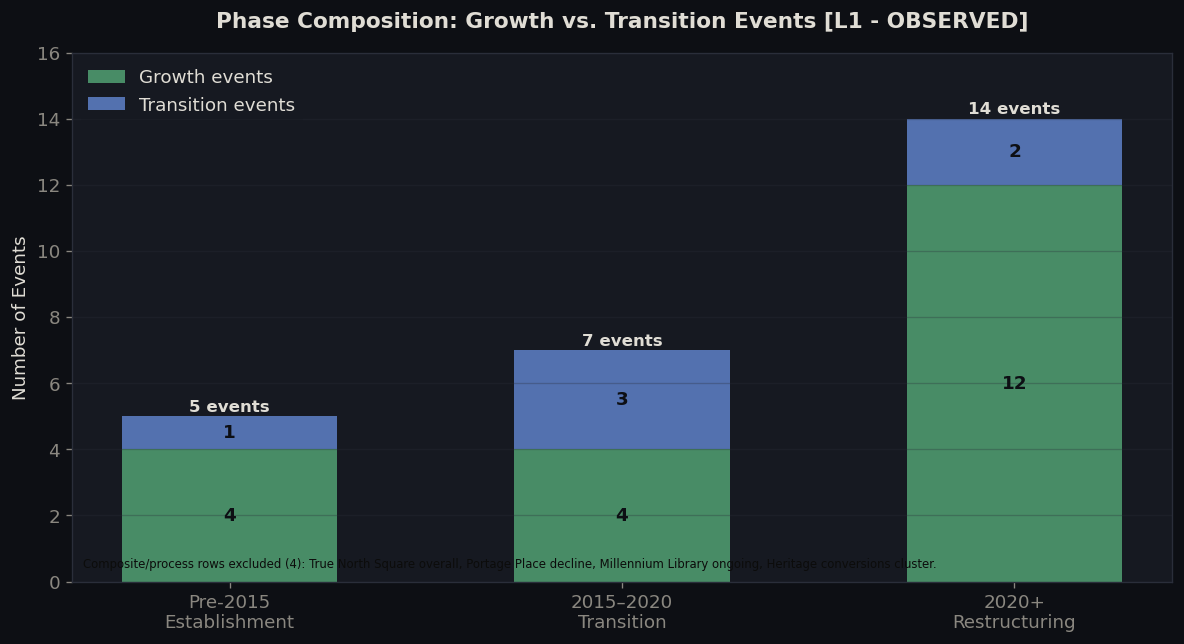

In [35]:
# Keep only discrete events (exclude composite process rows like "Portage Place decline")
discrete = gantt[gantt['row_type'] == 'discrete']

phases = ['Pre-2015 establishment', '2015–2020 transition', '2020+ restructuring']
phase_labels = ['Pre-2015\nEstablishment', '2015–2020\nTransition', '2020+\nRestructuring']

# Count Growth and Transition events in each phase
growth_vals = [len(discrete[(discrete['phase'] == p) & (discrete['impact'] == 'Growth')]) for p in phases]
trans_vals  = [len(discrete[(discrete['phase'] == p) & (discrete['impact'] == 'Transition')]) for p in phases]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(phases))
w = 0.55

# Stacked bars — Growth on bottom, Transition on top
ax.bar(x, growth_vals, w, color=GROWTH_C, label='Growth events', alpha=0.9, edgecolor='none')
ax.bar(x, trans_vals,  w, color=TRANS_C,  label='Transition events', alpha=0.9, edgecolor='none',
       bottom=growth_vals)

# Add count labels inside and above bars
for i, (g, t) in enumerate(zip(growth_vals, trans_vals)):
    total = g + t
    ax.text(i, total + 0.15, f'{total} events',
            ha='center', fontsize=10, fontweight='bold', color='#e0ddd5')
    if g > 0:
        ax.text(i, g / 2, f'{g}', ha='center', va='center',
                fontsize=11, fontweight='bold', color='#0d0f14')
    if t > 0:
        ax.text(i, g + t / 2, f'{t}', ha='center', va='center',
                fontsize=11, fontweight='bold', color='#0d0f14')

ax.set_xticks(x)
ax.set_xticklabels(phase_labels, fontsize=11)
ax.set_ylabel('Number of Events')
ax.set_title('Phase Composition: Growth vs. Transition Events [L1 - OBSERVED]',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', framealpha=0.3, edgecolor='none')
ax.set_ylim(0, max(g + t for g, t in zip(growth_vals, trans_vals)) + 2)
ax.grid(axis='y', alpha=0.3)

# Footnote: what was excluded
ax.text(0.01, 0.02,
        'Composite/process rows excluded (4): True North Square overall, '
        'Portage Place decline, Millennium Library ongoing, Heritage conversions cluster.',
        transform=ax.transAxes, fontsize=7, color="#0c0c0b", va='bottom')

plt.tight_layout()
plt.savefig('../visuals/fig_phase_composition.png', bbox_inches='tight', facecolor='#0d0f14')
plt.show()

#### Key Findings & Why this matters - Phase Composition `[L1]`

- The **2020+ restructuring phase** has the highest discrete event count, driven mainly by Growth-classified events
- The **2015–2020 transition phase** is relatively mixed, with Growth and Transition events occurring side by side as major investment coexisted with retail and commercial disruption
- **Pre-2015** is anchored primarily by civic and institutional infrastructure, including the CMHR, RBC Convention Centre expansion, and the return of the Jets

> **Why this matters:** The shift toward Growth-classified events in the 2020+ phase does not automatically mean commercial conditions are improving. Many of these events represent structural *conversion* rather than traditional expansion, such as retail anchor to residential or vacant office to institutional use. Positive investment signals do not necessarily translate into immediate economic recovery. That distinction is central to the interpretation that follows.

### Visualization 2 - Business License Activity (2010–2024) `[L1 (2021+) / L2 (2010–2020)]`

This section shows downtown business activity trends. **The data is indexed to 2013=100** so that relative trajectory is visible without implying precision in the absolute counts pre-2021.  

Index base: 2013 = 100
2024 indices — Retail: 36.8  Office: 56.6  Food: 65.6


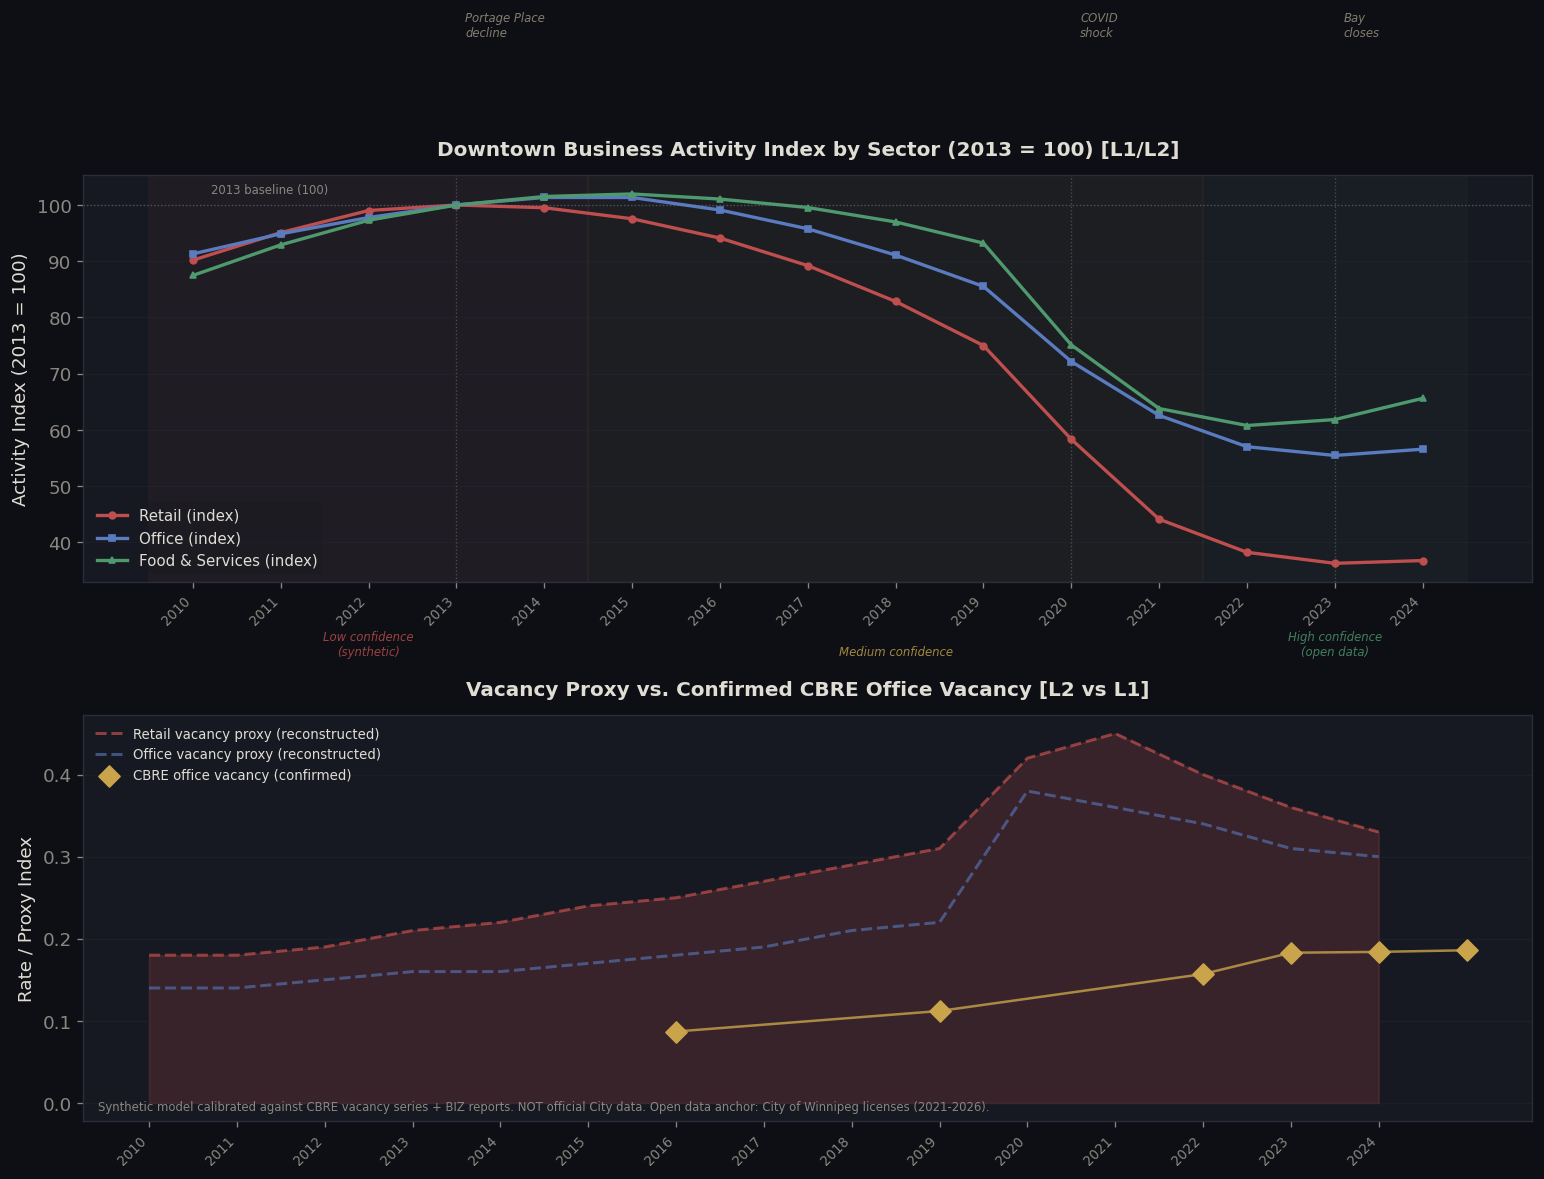

In [36]:
# [L1 / L2 - RECONSTRUCTED BUSINESS ACTIVITY MODEL]

# 1. Load synthetic model sheets
xl     = pd.ExcelFile('../data/Winnipeg_Synthetic_License_Model_2010_2024.xlsx')
retail = xl.parse('Retail License Flows')
office = xl.parse('Office License Flows')
food   = xl.parse('Food & Services')
syn    = xl.parse('Combined Summary')
syn    = syn.dropna(subset=['Year'])
syn['Year'] = syn['Year'].astype(int)

# 2. INDEX TO 2013 = 100 
# This avoids claiming precise absolute license counts from the synthetic model.
# We only use it to show the DIRECTION and MAGNITUDE of change relative to 2013.
base_year = 2013

retail_base = retail.loc[retail['Year']==base_year, 'Active Estimate'].values[0]
office_base = office.loc[office['Year']==base_year, 'Active Estimate'].values[0]
food_base   = food.loc[food['Year']==base_year,   'Active Estimate'].values[0]

retail['idx'] = (retail['Active Estimate'] / retail_base) * 100
office['idx'] = (office['Active Estimate'] / office_base) * 100
food['idx']   = (food['Active Estimate']   / food_base)   * 100

print(f"Index base: {base_year} = 100")
print(f"2024 indices — Retail: {retail.loc[retail['Year']==2024,'idx'].values[0]:.1f}  "
      f"Office: {office.loc[office['Year']==2024,'idx'].values[0]:.1f}  "
      f"Food: {food.loc[food['Year']==2024,'idx'].values[0]:.1f}")

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# TOP: Indexed activity (2013=100)
ax = axes[0]

ax.plot(retail['Year'], retail['idx'], color=DECLINE_C, linewidth=2.0,
        label='Retail (index)', marker='o', markersize=4)
ax.plot(office['Year'], office['idx'], color=TRANS_C,   linewidth=2.0,
        label='Office (index)', marker='s', markersize=4)
ax.plot(food['Year'],   food['idx'],   color=GROWTH_C,  linewidth=2.0,
        label='Food & Services (index)', marker='^', markersize=4)

# Horizontal reference line at 100 (= 2013 baseline)
ax.axhline(y=100, color='#8a8780', linewidth=0.8, linestyle=':', alpha=0.5)
ax.text(2010.2, 102, '2013 baseline (100)', fontsize=7, color='#8a8780')

# Confidence shading — Fixes the SyntaxError by using \n for newlines
ax.axvspan(2009.5, 2014.5, alpha=0.06, color=DECLINE_C)
ax.axvspan(2014.5, 2021.5, alpha=0.04, color=ACCENT)
ax.axvspan(2021.5, 2024.5, alpha=0.04, color=GROWTH_C)

ax.text(2012,  20, 'Low confidence\n(synthetic)', ha='center', fontsize=7,
        color=DECLINE_C, fontstyle='italic', alpha=0.8)
ax.text(2018,  20, 'Medium confidence', ha='center', fontsize=7,
        color=ACCENT, fontstyle='italic', alpha=0.8)
ax.text(2023,  20, 'High confidence\n(open data)', ha='center', fontsize=7,
        color=GROWTH_C, fontstyle='italic', alpha=0.8)

# Key event markers — Fixes the SyntaxError with \n
for yr, lbl in [(2013, 'Portage Place\ndecline'), (2020, 'COVID\nshock'), (2023, 'Bay\ncloses')]:
    ax.axvline(x=yr, color='#847D6E', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.text(yr + 0.1, 130, lbl, fontsize=7, color='#847D6E', fontstyle='italic')

ax.set_ylabel('Activity Index (2013 = 100)')
ax.set_title('Downtown Business Activity Index by Sector (2013 = 100) [L1/L2]',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(framealpha=0.3, edgecolor='none', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(syn['Year'])
ax.set_xticklabels(syn['Year'], rotation=45, ha='right', fontsize=8)

# BOTTOM: Vacancy proxy vs confirmed CBRE 
ax2 = axes[1]

# Plot retail vacancy proxy from synthetic model
ax2.fill_between(retail['Year'], retail['Vacancy Proxy Index'],
                  alpha=0.2, color=DECLINE_C)
ax2.plot(retail['Year'], retail['Vacancy Proxy Index'],
         color=DECLINE_C, linewidth=1.8, linestyle='--', alpha=0.7,
         label='Retail vacancy proxy (reconstructed)')

# Plot office vacancy proxy from synthetic model
ax2.plot(office['Year'], office['Vacancy Proxy Index'],
         color=TRANS_C, linewidth=1.8, linestyle='--', alpha=0.6,
         label='Office vacancy proxy (reconstructed)')

# Overlay confirmed CBRE office vacancy points for comparison
cbre_years = [2016, 2019, 2022, 2023, 2024, 2025]
cbre_rates  = [0.087, 0.112, 0.157, 0.183, 0.184, 0.186]
ax2.scatter(cbre_years, cbre_rates, color=ACCENT, s=80, zorder=5,
            marker='D', label='CBRE office vacancy (confirmed)')
ax2.plot(cbre_years, cbre_rates, color=ACCENT, linewidth=1.5,
         linestyle='-', alpha=0.8)

ax2.set_ylabel('Rate / Proxy Index')
ax2.set_title('Vacancy Proxy vs. Confirmed CBRE Office Vacancy [L2 vs L1]',
              fontsize=12, fontweight='bold', pad=12)
ax2.legend(framealpha=0.3, edgecolor='none', fontsize=8)
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks(syn['Year'])
ax2.set_xticklabels(syn['Year'], rotation=45, ha='right', fontsize=8)

ax2.text(0.01, 0.02,
         'Synthetic model calibrated against CBRE vacancy series + BIZ reports. '
         'NOT official City data. Open data anchor: City of Winnipeg licenses (2021-2026).',
         transform=ax2.transAxes, fontsize=7, color='#8a8780', va='bottom')

plt.tight_layout()
plt.savefig('../visuals/fig_business_activity.png', bbox_inches='tight', facecolor='#0d0f14')
plt.show()

#### Key Findings - Business Activity `[L1/L2]`

- The **retail activity index** fell from **100 in 2013** to about **37 by 2024**, indicating the steepest decline of the three sectors
- **Food & Services** shows the strongest post-2020 recovery, while **office activity** stabilizes somewhat but remains well below its earlier level
- The decline is not uniform across sectors: retail weakens most sharply, office declines more gradually, and Food & Services recovers modestly after the pandemic shock
- The lower panel shows that the reconstructed vacancy proxy follows the general direction of the confirmed **CBRE office vacancy** series, but it should still be treated as a directional support layer rather than a calibrated absolute measure
- Pre-2021 business activity values are **reconstructed estimates**, so the trend direction is more defensible than the exact magnitudes

> **Why this matters:** This figure shows why the downtown cannot be described by investment alone. Even while major capital projects move forward, current business activity remains weak, especially in retail. That does not necessarily contradict the investment story. It suggests that short-term commercial conditions and long-term structural redevelopment are operating on different timelines.

### Visualization 3 - Office Vacancy Rate with Seaborn (2016–2025) `[L1 - OBSERVED]`

Office vacancy is the most direct measure of short-term commercial health. It has doubled over nine years - and the trajectory has not yet reversed.

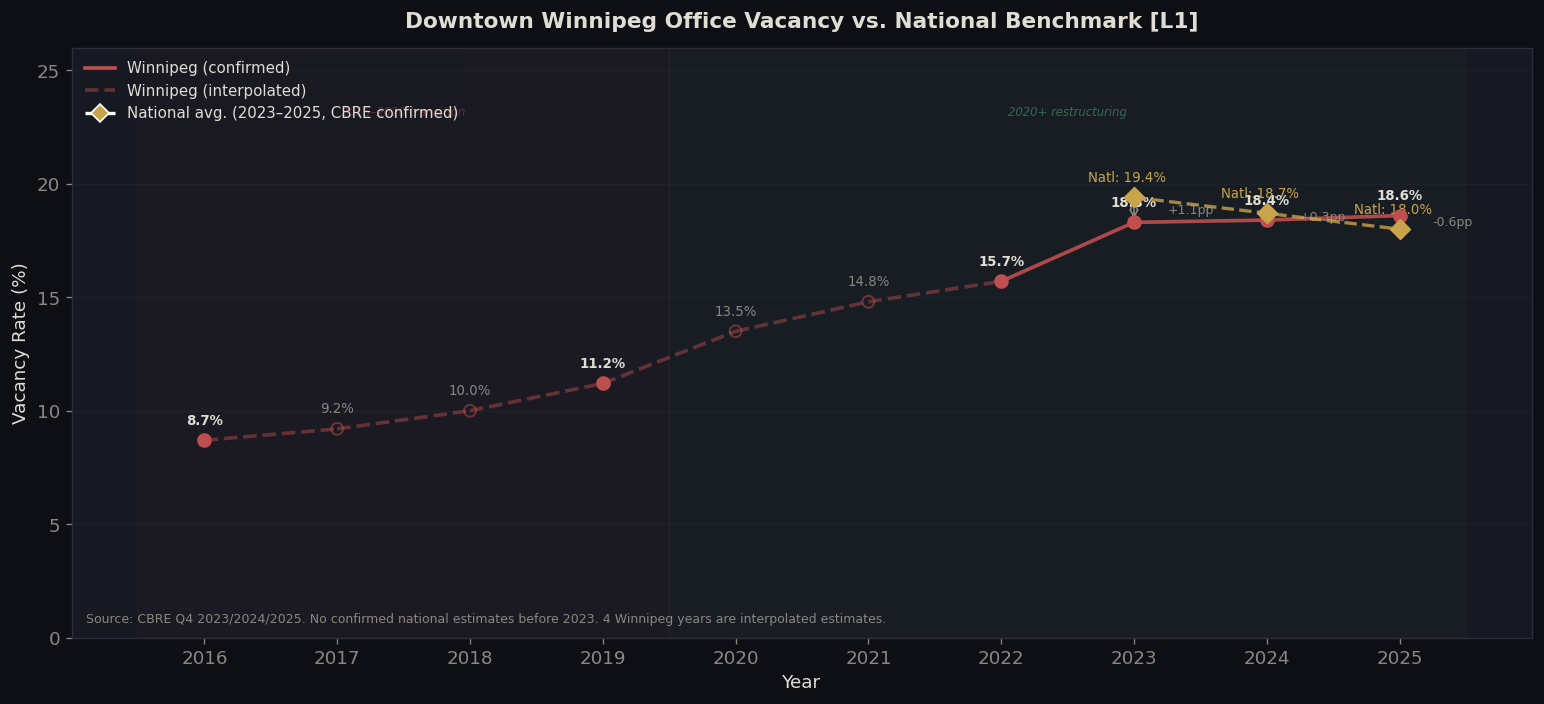

In [37]:
# Winnipeg vacancy data - confirmed CBRE figures with interpolated gaps
vac = pd.DataFrame({
    'Year':      [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Rate':      [8.7,  9.2,  10.0, 11.2, 13.5, 14.8, 15.7, 18.3, 18.4, 18.6],
    'Confirmed': [True, False, False, True, False, False, True, True, True, True]
})

# National benchmark - only 3 confirmed years available
national = pd.DataFrame({
    'Year':          [2023, 2024, 2025],
    'National_Rate': [19.4, 18.7, 18.0],
})

fig, ax = plt.subplots(figsize=(13, 6))

# Draw line segments - solid where both endpoints are confirmed, dashed where interpolated
for i in range(len(vac) - 1):
    x0, y0, c0 = vac.iloc[i]['Year'],   vac.iloc[i]['Rate'],   vac.iloc[i]['Confirmed']
    x1, y1, c1 = vac.iloc[i+1]['Year'], vac.iloc[i+1]['Rate'], vac.iloc[i+1]['Confirmed']
    both_confirmed = c0 and c1
    ax.plot([x0, x1], [y0, y1], color=DECLINE_C, linewidth=2.2,
            linestyle='-' if both_confirmed else '--',
            alpha=0.9 if both_confirmed else 0.45)

# Draw data points - filled = confirmed, open circle = interpolated
for _, r in vac.iterrows():
    if r['Confirmed']:
        ax.scatter(r['Year'], r['Rate'], color=DECLINE_C, s=60, zorder=5)
        ax.text(r['Year'], r['Rate'] + 0.7, f"{r['Rate']}%",
                ha='center', fontsize=8, fontweight='bold', color='#e0ddd5')
    else:
        ax.scatter(r['Year'], r['Rate'], color=DECLINE_C, s=50, zorder=5,
                   facecolors='none', edgecolors=DECLINE_C, linewidths=1.2, alpha=0.5)
        ax.text(r['Year'], r['Rate'] + 0.7, f"{r['Rate']}%",
                ha='center', fontsize=8, color='#8a8780')

# National benchmark line
ax.plot(national['Year'], national['National_Rate'],
        color=ACCENT, linewidth=2.0, linestyle='--', alpha=0.8, zorder=4)
ax.scatter(national['Year'], national['National_Rate'],
           color=ACCENT, marker='D', s=70, zorder=5)
for _, r in national.iterrows():
    ax.text(r['Year'] - 0.05, r['National_Rate'] + 0.7,
            f"Natl: {r['National_Rate']}%", ha='center', fontsize=8, color=ACCENT)

# Annotate the gap between Winnipeg and national for each confirmed year
for _, r in national.iterrows():
    wpg  = vac[vac['Year'] == r['Year']].iloc[0]['Rate']
    diff = r['National_Rate'] - wpg
    mid  = (wpg + r['National_Rate']) / 2
    ax.annotate('', xy=(r['Year'], r['National_Rate']), xytext=(r['Year'], wpg),
                arrowprops=dict(arrowstyle='<->', color='#8a8780', lw=1))
    ax.text(r['Year'] + 0.25, mid, f"{'+' if diff>0 else ''}{diff:.1f}pp",
            fontsize=7.5, color='#8a8780', va='center')

# Lightly shade the phase periods
ax.axvspan(2015.5, 2019.5, alpha=0.03, color=DECLINE_C)
ax.axvspan(2019.5, 2025.5, alpha=0.03, color=GROWTH_C)
ax.text(2017.5, 23, '2015–2020 transition', ha='center', fontsize=7,
        color=DECLINE_C, fontstyle='italic', alpha=0.6)
ax.text(2022.5, 23, '2020+ restructuring', ha='center', fontsize=7,
        color=GROWTH_C, fontstyle='italic', alpha=0.6)

ax.set_xlabel('Year')
ax.set_ylabel('Vacancy Rate (%)')
ax.set_title('Downtown Winnipeg Office Vacancy vs. National Benchmark [L1]',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 26)
ax.set_xticks(vac['Year'])
ax.grid(axis='y', alpha=0.3)

conf_line = plt.Line2D([0],[0], color=DECLINE_C, linewidth=2.2,
                        label='Winnipeg (confirmed)')
est_line  = plt.Line2D([0],[0], color=DECLINE_C, linewidth=2.2,
                        linestyle='--', alpha=0.45, label='Winnipeg (interpolated)')
nat_line  = plt.Line2D([0],[0], marker='D', color='w', markerfacecolor=ACCENT,
                        markersize=8, linestyle='--', linewidth=2.0,
                        label='National avg. (2023–2025, CBRE confirmed)')
ax.legend(handles=[conf_line, est_line, nat_line],
          framealpha=0.3, edgecolor='none', fontsize=9, loc='upper left')

ax.text(0.01, 0.02,
        'Source: CBRE Q4 2023/2024/2025. No confirmed national estimates before 2023. '
        '4 Winnipeg years are interpolated estimates.',
        transform=ax.transAxes, fontsize=7.5, color='#8a8780', va='bottom')

plt.tight_layout()
plt.savefig('../visuals/fig_vacancy.png', bbox_inches='tight', facecolor='#0d0f14')
plt.show()


#### Key Findings - Office Vacancy `[L1]`

- Downtown Winnipeg office vacancy rose from **8.7% in 2016** to **18.6% in 2025**, meaning it more than doubled over the period shown
- Winnipeg remained **below** the national benchmark in **2023** and **2024**, but moved **above** it in **2025**
- The 2025 crossover is real, but it should be interpreted carefully because the national comparison is only available for three years
- Four Winnipeg values in the series are interpolated, so they should be treated as continuity estimates rather than directly sourced observations

> **Why this matters:** The chart shows that downtown office conditions remain materially weaker than they were a decade ago. At the same time, the comparison to the national benchmark suggests that Winnipeg’s trajectory is not explained by a simple local collapse narrative alone. The more accurate reading is that office weakness remains part of a broader restructuring process whose long-term outcome is still unresolved.

### Visualization 4 - Category × Phase Matrix `[L3 - INFERRED]`  

This heatmap asks how event categories are distributed across the three major downtown phases. Instead of reading the project as a timeline, this view turns the structural event dataset into a category-by-phase matrix so it is easier to see which kinds of events dominate each period.

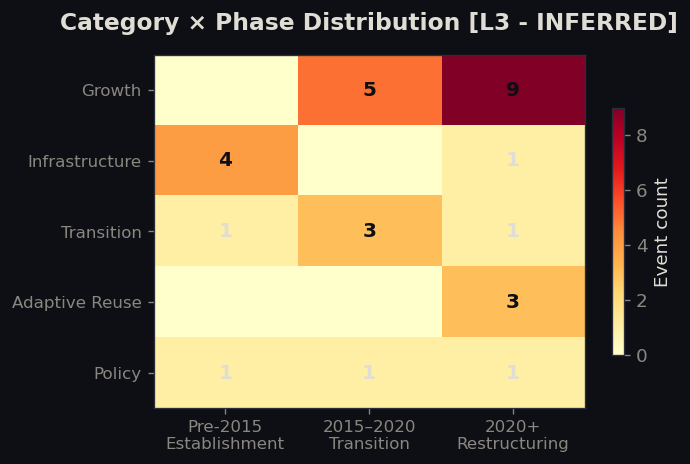

In [38]:
# [L3 - INFERRED: CATEGORY × PHASE MATRIX]

# Cross-tabulate: how many events of each category fall in each phase?
phase_order = ['Pre-2015 establishment', '2015–2020 transition', '2020+ restructuring']
ct = pd.crosstab(gantt['category'], gantt['phase'])
ct = ct.reindex(columns=phase_order, fill_value=0)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(6, 4))

# imshow creates a heatmap - darker cells = more events
im = ax.imshow(ct.values, cmap='YlOrRd', aspect='auto', vmin=0)

ax.set_xticks(range(len(phase_order)))
ax.set_xticklabels(['Pre-2015\nEstablishment', 
                    '2015–2020\nTransition',
                    '2020+\nRestructuring'], fontsize=10)
ax.set_yticks(range(len(ct)))
ax.set_yticklabels(ct.index, fontsize=10)

# Add count labels in each cell
for i in range(len(ct)):
    for j in range(len(phase_order)):
        val = ct.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='#0d0f14' if val >= 2 else '#e0ddd5')

ax.set_title('Category × Phase Distribution [L3 - INFERRED]',
             fontsize=14, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, label='Event count', shrink=0.7)
plt.tight_layout()
plt.savefig('../visuals/fig_heatmap.png', bbox_inches='tight', facecolor='#0d0f14')
plt.show()

#### Key Findings - Category × Phase `[L3]`

- **Growth** events are most concentrated in the **2020+ restructuring** phase
- **Transition** events are most concentrated in the **2015–2020 transition** phase
- **Infrastructure** is concentrated mainly in the **Pre-2015** phase, with only limited presence afterward
- **Adaptive Reuse** appears almost entirely in the **2020+** phase, reinforcing the interpretation that recent investment is focused more on conversion than on traditional expansion

> **Why this matters:** The heatmap makes the phase story easier to read as a matrix rather than a timeline. The 2015–2020 concentration of Transition events aligns with the period of visible commercial disruption, while the 2020+ concentration of Growth and Adaptive Reuse events can be read as the structural response. This does not prove recovery, but it does support the interpretation that the downtown is being reshaped through conversion.

### Visualization 5 - Residential Pipeline `[L1/L2 - OBSERVED/RECONSTRUCTED]`

The residential pipeline is the forward-looking signal that gives the investment story its logic. Without a significant increase in downtown residents, the adaptive reuse conversions in Sections 3 and 6 cannot generate the organic ground-floor demand needed to reduce vacancy. This section quantifies what is committed, what is delivered, and what remains to be tested.

> **Note — January 2026 update:** On January 27, 2026, CentreVenture announced a further 297 units across four heritage building conversions, backed by $4.65M from the City of Winnipeg, the federal Housing Accelerator Fund, and the Gail Parvin Hammerquist Fund. The two largest are:
> - **St. Charles Hotel** (235 Notre Dame Ave) - 140-unit conversion of a vacant 113-year-old hotel, with 11-storey addition preserving the heritage facade. Developer: Ken Zaifman / Penfor Construction. `[L1 - OBSERVED, strong source: CBC News Jan 27 2026]`
> - **Maw's Garage / Sanford Building** (291 Bannatyne Ave) - 114-unit residential tower incorporating a 1907 garage and 1890 Sanford building in the Exchange District. Developer: Fratelli Enterprises / Sabino Tummillo. City heritage permit approved over HBRC objection. `[L1 - OBSERVED, strong source: CBC News Jan 27 2026; moderate corroboration: Residents of the Exchange District Apr 2025]`
>
> These projects are announced but not yet added to `housing_pipeline_2026.csv`. They are noted here as a confirmed pipeline addition. When incorporated, the model-ready unit range rises from 1,381-1,539 to approximately **1,635-1,793** (excluding the remaining 43 units across the Belgica Block and Alloway Building).


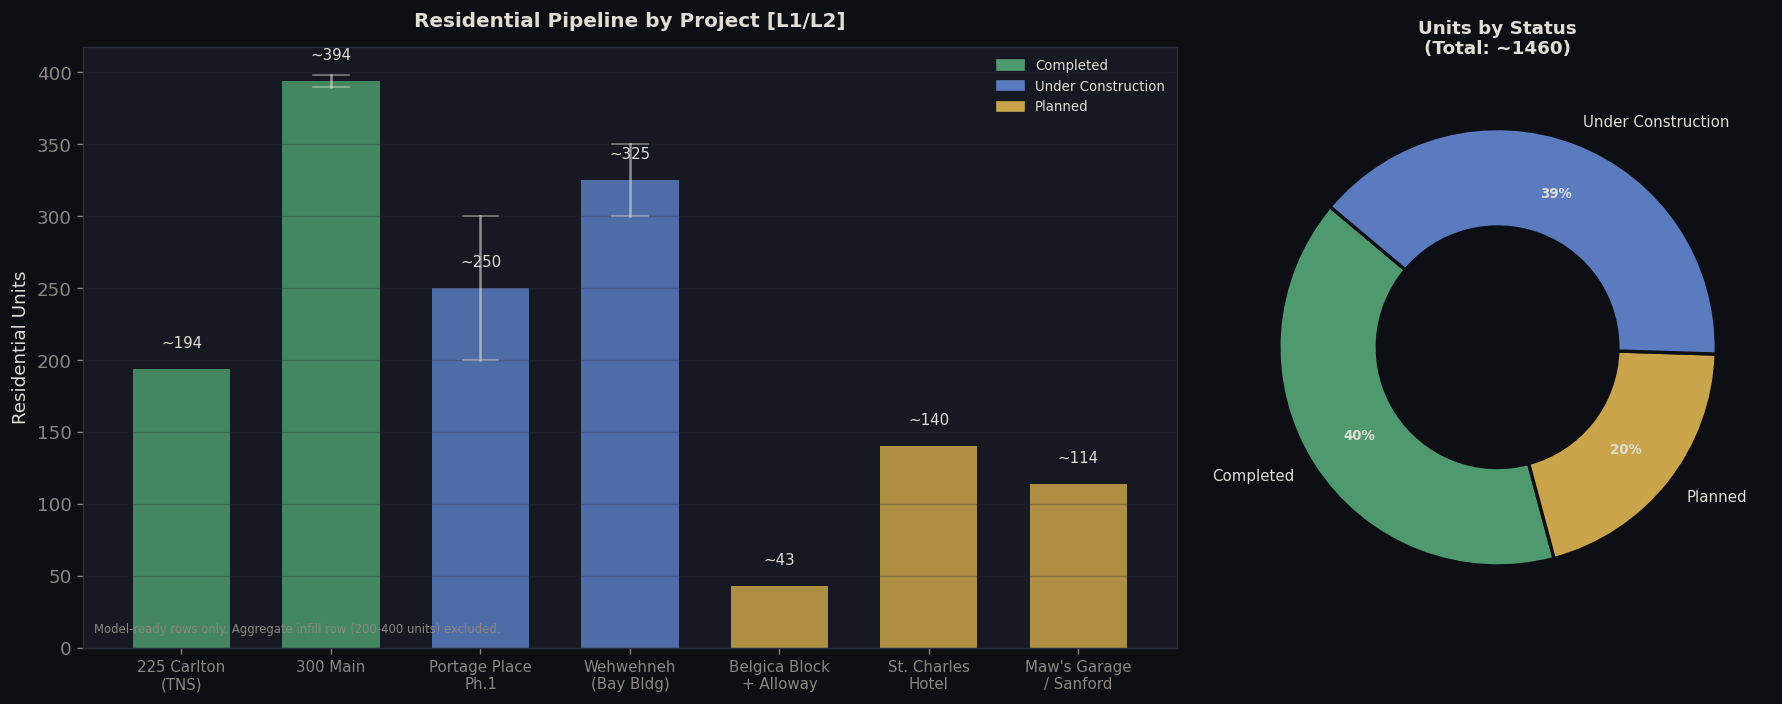

In [39]:
# [L1/L2 - RESIDENTIAL PIPELINE ANALYSIS]

# Use model-ready rows only (aggregate infill excluded)
housing_model = housing[housing['include_in_model']].copy()
housing_model['units_mid'] = (housing_model['units_low'] + housing_model['units_high']) / 2

status_colors = {
    'Completed':          GROWTH_C,
    'Under Construction': TRANS_C,
    'Planned':            ACCENT,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6),
                                gridspec_kw={'width_ratios': [2, 1]})

# Fixed: Using \n for line breaks instead of physical Enter keys
short_labels = ['225 Carlton\n(TNS)', '300 Main', 'Portage Place\nPh.1',
                'Wehwehneh\n(Bay Bldg)', 'Belgica Block\n+ Alloway',
                'St. Charles\nHotel', "Maw's Garage\n/ Sanford"]

for i, (_, row) in enumerate(housing_model.iterrows()):
    c = status_colors.get(row['phase_status'], '#7a7a7a')
    ax1.bar(i, row['units_mid'], color=c, alpha=0.85, width=0.65, edgecolor='none')

    # Error bars show the low-high range
    if row['units_low'] != row['units_high']:
        ax1.plot([i, i], [row['units_low'], row['units_high']],
                 color='#e0ddd5', lw=1.5, alpha=0.6)
        for bound in [row['units_low'], row['units_high']]:
            ax1.plot([i-.12, i+.12], [bound]*2, color='#e0ddd5', lw=1, alpha=0.5)

    ax1.text(i, row['units_mid'] + 15, f"~{int(row['units_mid'])}",
             ha='center', fontsize=9, color='#e0ddd5')

ax1.set_xticks(range(len(housing_model)))
ax1.set_xticklabels(short_labels, fontsize=9)
ax1.set_ylabel('Residential Units')
ax1.set_title('Residential Pipeline by Project [L1/L2]', fontsize=12,
              fontweight='bold', pad=12)
ax1.grid(axis='y', alpha=0.3)

handles = [mpatches.Patch(color=v, label=k) for k, v in status_colors.items()]
ax1.legend(handles=handles, fontsize=8, framealpha=0.3, edgecolor='none')

ax1.text(0.01, 0.02,
         'Model-ready rows only. Aggregate infill row (200-400 units) excluded.',
         transform=ax1.transAxes, fontsize=7, color='#8a8780', va='bottom')

# Pie: unit share by status
status_totals = housing_model.groupby('phase_status')['units_mid'].sum()
colors_pie    = [status_colors.get(s, '#7a7a7a') for s in status_totals.index]
wedges, texts, autotexts = ax2.pie(
    status_totals.values, labels=status_totals.index,
    colors=colors_pie, autopct='%1.0f%%',
    wedgeprops=dict(width=0.45, edgecolor='#0d0f14', linewidth=2),
    startangle=140, pctdistance=0.75)
for t in texts:     t.set_color('#e0ddd5'); t.set_fontsize(9)
for t in autotexts: t.set_color('#e0ddd5'); t.set_fontsize(8); t.set_fontweight('bold')

# Fixed: Using \n for the title line break
ax2.set_title(f"Units by Status\n(Total: ~{int(housing_model['units_mid'].sum())})",
              fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('../visuals/fig_residential.png', bbox_inches='tight', facecolor='#0d0f14')
plt.show()

#### Key Findings - Residential Pipeline `[L1/L2]`

- The current model-ready housing dataset contains approximately **1,381–1,539 units**, with a midpoint total of about **1,460 units**
- About **40%** of those midpoint units are already **delivered**, while the remaining majority are still **under construction or planned**
- The pipeline is concentrated in a small number of major projects, especially **300 Main**, **Wehwehneh**, and **Portage Place Phase 1**
- This means the residential demand story is partly visible already, but much of the expected downtown population growth is still future-oriented rather than fully realized

> **Why this matters:** This chart helps explain why large-scale investment and weak short-term commercial conditions can coexist. A substantial share of the residential supply that is supposed to support future ground-floor demand is either still being built or not yet delivered. The pipeline is real, but much of its street-level economic effect is still pending.

### Visualization 6 - Capital Investment Scale `[L1 - OBSERVED]`

The investment picture is the other half of the structural argument. If Section 5 shows the current weakness in commercial vitality, this section shows what is being bet against it - and crucially, *what kind* of bet it is.


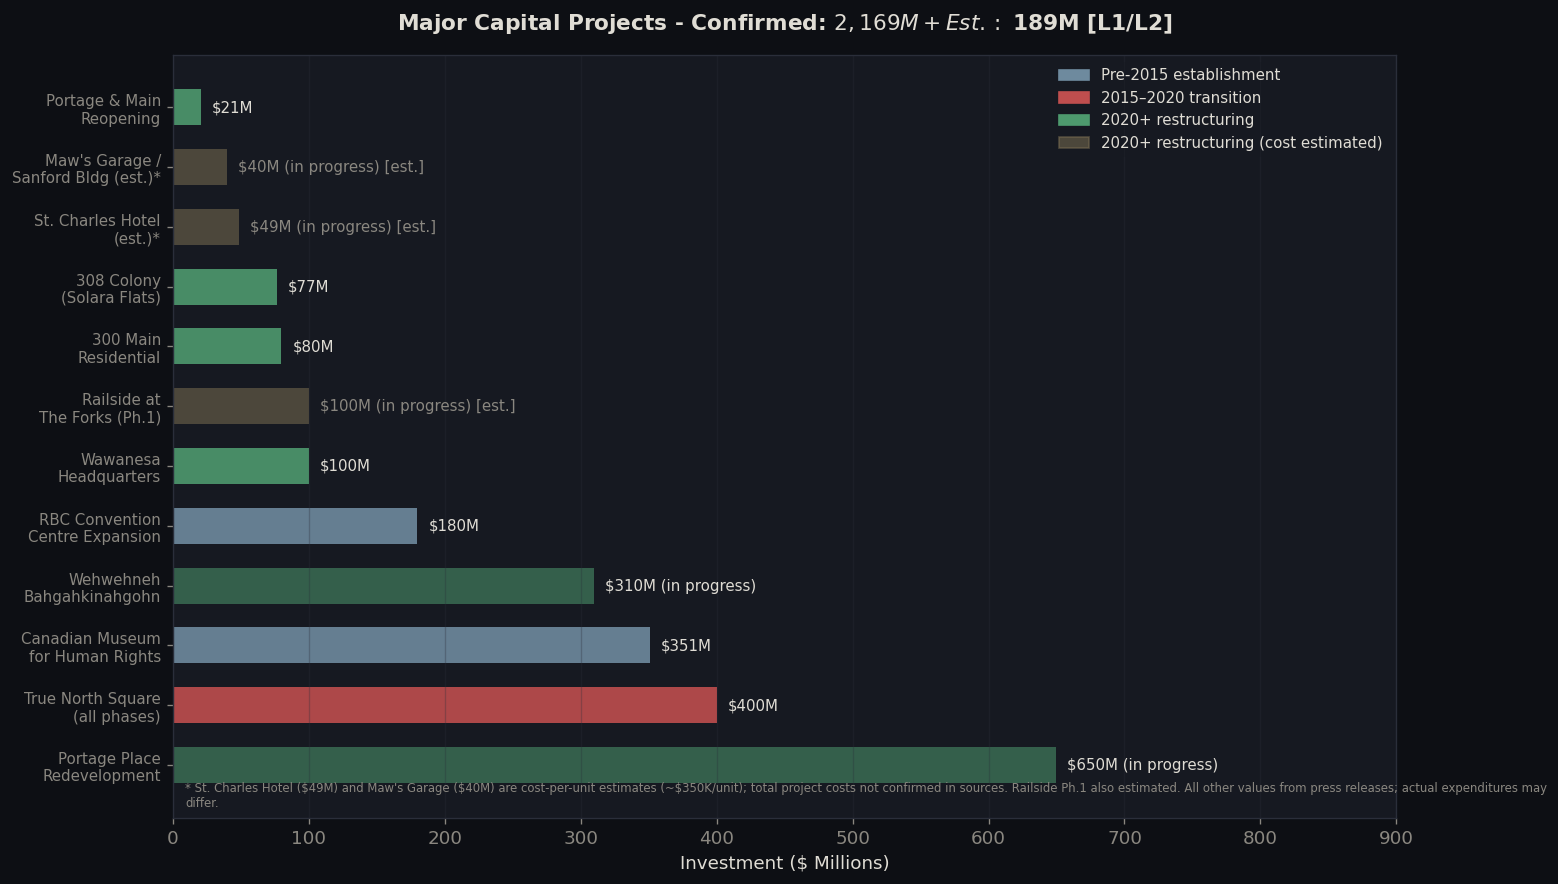

In [40]:
# [L1 - OBSERVED CAPITAL INVESTMENT SCALE]

# Investment data - manually compiled from press releases and CBC/BIZ sources
# See downtown_wpg_sources_v5.csv for full source attribution
#
# NOTE on St. Charles Hotel and Maw's Garage:
# Total project costs are NOT confirmed in available sources.
# Only the public funding contribution ($4.65M combined) is confirmed (CBC, Jan 27 2026).
# These are plotted as L2 estimates using a cost-per-unit proxy (~$350K/unit heritage conversion),
# which is consistent with comparable Winnipeg adaptive reuse projects.
# They are flagged with '*' and a separate colour to distinguish estimated from confirmed values.

inv = pd.DataFrame({
    'Project': [
        'Portage Place\nRedevelopment',
        'True North Square\n(all phases)',
        'Canadian Museum\nfor Human Rights',
        'Wehwehneh\nBahgahkinahgohn',
        'RBC Convention\nCentre Expansion',
        'Wawanesa\nHeadquarters',
        'Railside at\nThe Forks (Ph.1)',
        '300 Main\nResidential',
        '308 Colony\n(Solara Flats)',
        'St. Charles Hotel\n(est.)*',
        'Maw\'s Garage /\nSanford Bldg (est.)*',
        'Portage & Main\nReopening',
    ],
    'Amount_M': [650, 400, 351, 310, 180, 100, 100, 80, 77, 49, 40, 21],
    'Phase': [
        '2020+ restructuring', '2015–2020 transition', 'Pre-2015 establishment',
        '2020+ restructuring', 'Pre-2015 establishment', '2020+ restructuring',
        '2020+ restructuring', '2020+ restructuring', '2020+ restructuring',
        '2020+ restructuring', '2020+ restructuring',
        '2020+ restructuring',
    ],
    'Done':      [False, True, True, False, True, True, False, True, True, False, False, True],
    'Confirmed': [True,  True, True, True,  True, True, False, True, True, False, False, True],
})

fig, ax = plt.subplots(figsize=(13, 7.5))

for i, row in inv.iterrows():
    # Confirmed projects use phase colour; estimated use a muted grey-gold
    bar_color = PHASE_COLORS[row['Phase']] if row['Confirmed'] else '#7a6e52'
    ax.barh(i, row['Amount_M'], height=0.6,
            color=bar_color,
            alpha=0.9 if row['Done'] else 0.55,
            edgecolor='none')
    suffix = '' if row['Done'] else ' (in progress)'
    est_tag = ' [est.]' if not row['Confirmed'] else ''
    ax.text(row['Amount_M'] + 8, i, f"${row['Amount_M']}M{suffix}{est_tag}",
            va='center', fontsize=9, color='#e0ddd5' if row['Confirmed'] else '#8a8780')

ax.set_yticks(range(len(inv)))
ax.set_yticklabels(inv['Project'], fontsize=9)
ax.set_xlabel('Investment ($ Millions)')

confirmed_total = inv[inv['Confirmed']]['Amount_M'].sum()
estimated_total = inv[~inv['Confirmed']]['Amount_M'].sum()
ax.set_title(
    f"Major Capital Projects - Confirmed: ${confirmed_total:,}M + Est.: ~${estimated_total}M [L1/L2]",
    fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 900)
ax.grid(axis='x', alpha=0.3)

ax.text(0.01, 0.01,
        '* St. Charles Hotel ($49M) and Maw\'s Garage ($40M) are cost-per-unit estimates (~$350K/unit); '
        'total project costs not confirmed in sources. Railside Ph.1 also estimated. '
        'All other values from press releases; actual expenditures may differ.',
        transform=ax.transAxes, fontsize=7, color='#8a8780', va='bottom', wrap=True)

handles = [mpatches.Patch(color=PHASE_COLORS[p], label=p)
           for p in ['Pre-2015 establishment', '2015–2020 transition', '2020+ restructuring']]
handles.append(mpatches.Patch(color='#7a6e52', alpha=0.55, label='2020+ restructuring (cost estimated)'))
ax.legend(handles=handles, loc='upper right', framealpha=0.3, edgecolor='none', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/fig_investment.png', bbox_inches='tight', facecolor='#0d0f14')
plt.show()


#### Key Findings - Capital Investment `[L1/L2]`

- The tracked capital pipeline includes roughly **$2.17B in confirmed investment** plus about **$189M in estimated project costs**, for a combined total near **$2.36B**
- The largest projects are concentrated in the **2020+ restructuring** phase, especially **Portage Place redevelopment ($650M)** and **Wehwehneh Bahgahkinahgohn ($310M)**
- Several of the biggest projects are still **in progress**, which means the investment is committed but not yet fully delivered
- The estimated projects are clearly marked and should be interpreted more cautiously than the confirmed figures

> **Why this matters:** The scale of tracked capital shows that Downtown Winnipeg is not simply experiencing decline. At the same time, the composition of that investment matters just as much as the total. Much of the recent capital is going into adaptive reuse, residential conversion, and institutional restructuring rather than restoring the old retail-centered downtown model. This supports the project’s argument that downtown is being reconfigured, not simply rebuilt in its previous form.

### Visualization 7 — Project Timeline (Gantt View) `[L1/L2 - OBSERVED/RECONSTRUCTED]`

Every structural event mapped by duration. Bar opacity encodes source quality: full = strong source, faded = weak source.

The timeline makes the investment-vitality disconnect visible at a glance: the largest cluster of active projects sits in 2024–2026, yet all of them extend past the current data window. Capital is deployed. Delivery is pending.


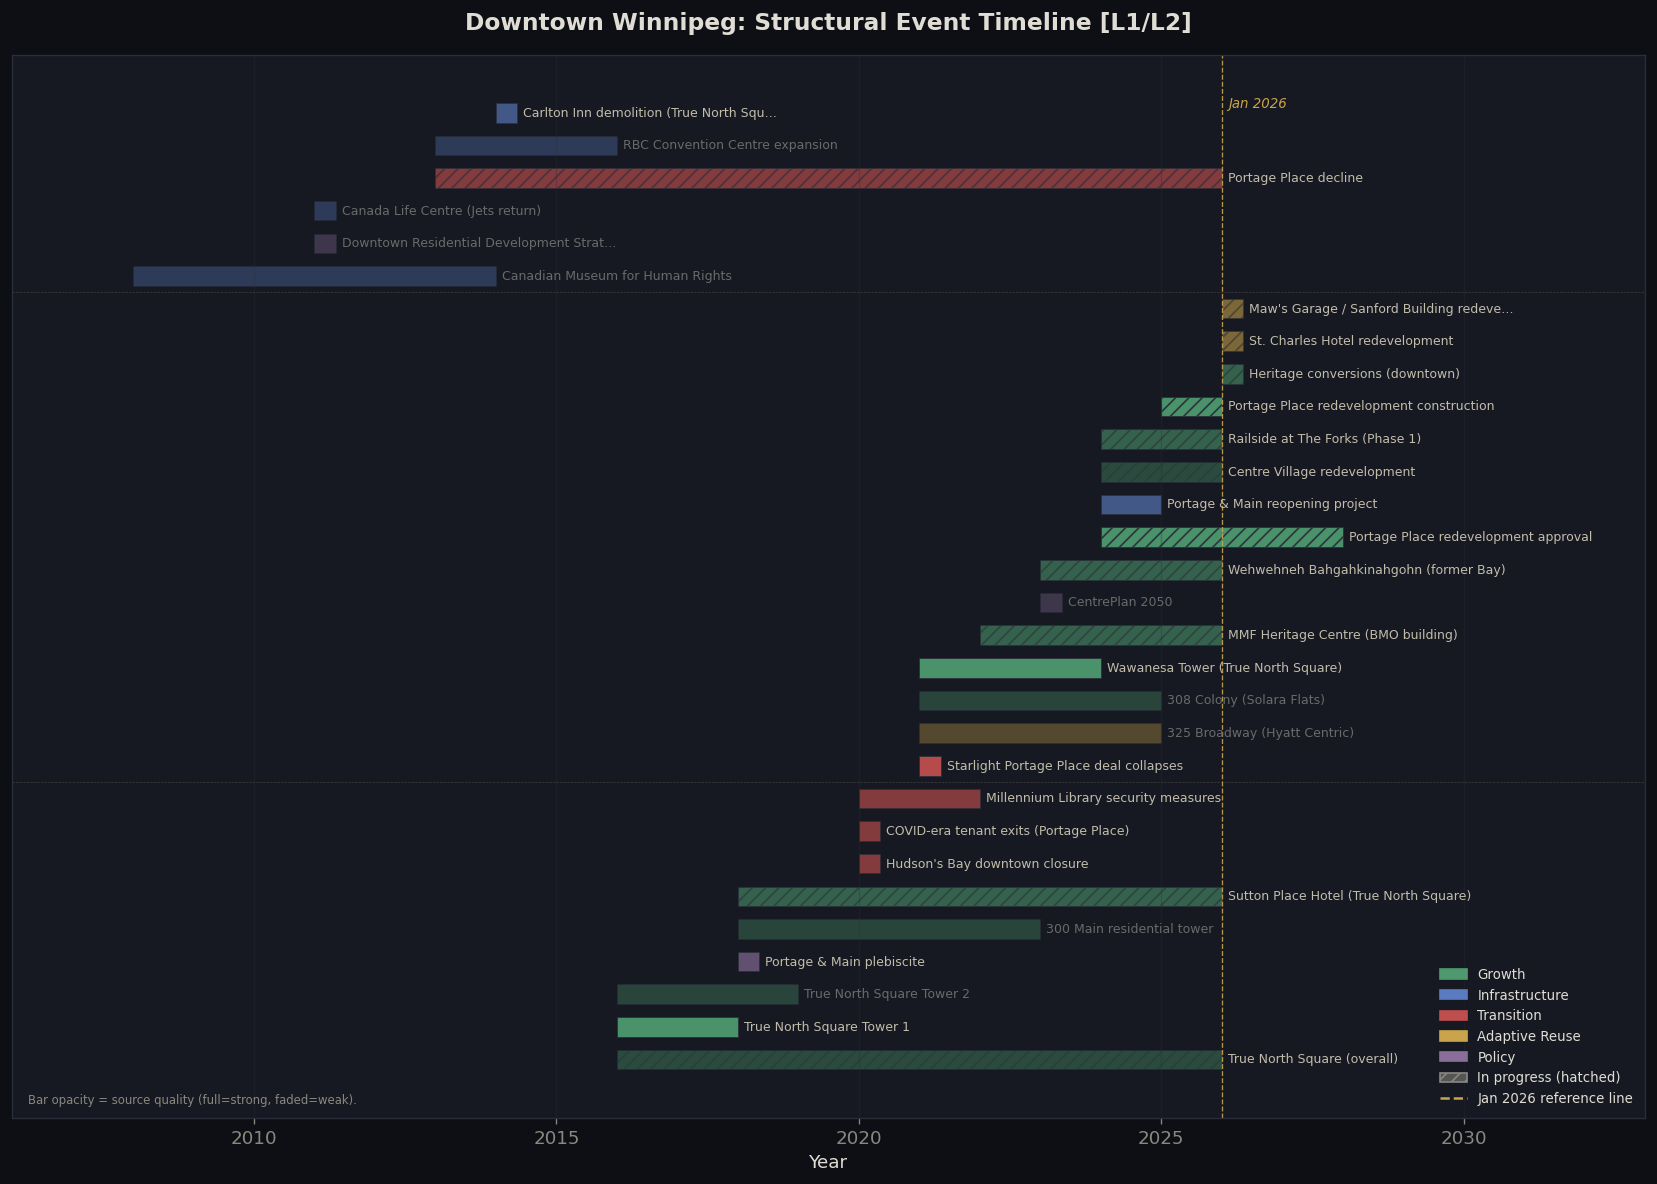

In [41]:
fig, ax = plt.subplots(figsize=(14, 10))

# Sort by phase, then start year, Growth before Transition
df_g = gantt.sort_values(
    ['phase', 'year_start', 'impact'],
    ascending=[True, True, False]
).reset_index(drop=True)

# Opacity levels based on how well-sourced each event is
opacity_map = {'strong': 0.95, 'moderate': 0.65, 'weak': 0.35}
prev_phase = None
PORTAGE_LABEL = 'Portage Place'

for i, row in df_g.iterrows():
    start = row['year_start']
    dur = max(row['year_end'] - start, 0.35)  # minimum width so short events are visible
    c = TYPE_COLORS.get(row['category'], '#7a7a7a')
    sq = str(row.get('source_quality', 'moderate'))
    base_alpha = opacity_map.get(sq, 0.65)

    # Portage Place: confirmed in active deconstruction — always hatched
    if PORTAGE_LABEL in str(row['task_name']) and not row['is_done']:
        hatch = '///'
        alpha = base_alpha
    else:
        # Solid bar = completed; hatched = in progress
        hatch = '' if row['is_done'] else '///'
        alpha = base_alpha if row['is_done'] else base_alpha * 0.6

    ax.barh(
        i, dur, left=start, height=0.6,
        color=c, alpha=alpha,
        edgecolor='#2a2e3a', linewidth=0.5, hatch=hatch
    )

    # Truncate long labels and draw them after the bar
    label = str(row['task_name'])
    if len(label) > 40:
        label = label[:38] + '…'
    txt_color = '#C2BCAB' if sq != 'weak' else '#6a6a6a'
    ax.text(start + dur + 0.1, i, label, va='center', fontsize=7.5, color=txt_color)

    # Draw a dividing line between phases
    if row['phase'] != prev_phase and prev_phase is not None:
        ax.axhline(y=i - 0.5, color='#847D6E', linewidth=0.4, alpha=0.4, linestyle='--')
    prev_phase = row['phase']

# Vertical line marking January 2026
JAN_2026_X = 2026.0
ax.axvline(x=JAN_2026_X, color=ACCENT, linewidth=0.8, linestyle='--', alpha=0.9)
ax.text(
    JAN_2026_X + 0.1, len(df_g) - 0.5, 'Jan 2026',
    color=ACCENT, fontsize=8, va='top', fontstyle='italic'
)

ax.set_xlim(2006, 2033)
ax.set_xlabel('Year')
ax.set_title(
    'Downtown Winnipeg: Structural Event Timeline [L1/L2]',
    fontsize=14, fontweight='bold', pad=15
)
ax.grid(axis='x', alpha=0.3)
ax.set_yticks([])  # labels are drawn inline

# Legend
type_patches = [
    mpatches.Patch(color=TYPE_COLORS[t], label=t)
    for t in ['Growth', 'Infrastructure', 'Transition', 'Adaptive Reuse', 'Policy']
]
prog_patch = mpatches.Patch(
    facecolor='#555', hatch='///', edgecolor='#8a8780',
    label='In progress (hatched)'
)
jan_line = plt.Line2D(
    [0], [0], color=ACCENT, linewidth=1.5, linestyle='--',
    label='Jan 2026 reference line'
)

ax.legend(
    handles=type_patches + [prog_patch, jan_line],
    loc='lower right', framealpha=0.3, edgecolor='none', fontsize=8
)

ax.text(
    0.01, 0.01,
    'Bar opacity = source quality (full=strong, faded=weak).',
    transform=ax.transAxes, fontsize=7, color='#8a8780', va='bottom'
)

plt.tight_layout()
plt.savefig('../visuals/fig_gantt.png', bbox_inches='tight', facecolor='#0d0f14')
plt.show()

#### Key Findings - Timeline `[L1/L2]`

- Construction and redevelopment activity is heavily concentrated in the post-2020 period, with the largest visible cluster active in 2024–2026
- Faded bars are concentrated more heavily among older events, showing that dedicated source quality is generally weaker for earlier timeline entries
- Several major projects remain in progress at the January 2026 reference line, showing that investment activity is ongoing even where final outcomes are not yet observable

> **Why this matters:** The concentration of hatched bars at and beyond the January 2026 reference line is not a gap in the dataset. It is the central empirical condition of this analysis. Investment is committed and construction is active, but many outcomes are still unresolved. This helps explain why high investment and weak downtown conditions can coexist: they reflect different stages of structural change.

### Visualization 8 — Spatial Distribution of Investment `[L1 - OBSERVED]`

Where are the projects located? This spatial plot maps major downtown events using project latitude and longitude coordinates to show where structural change is actually occurring across the core.  

This matters because investment is not distributed evenly across Downtown Winnipeg. Instead, it appears concentrated in specific redevelopment corridors, while other parts of downtown show fewer visible growth signals. That uneven geography is important for interpretation: aggregate indicators such as the Downtown Health Score can summarize the whole core, but they can also hide meaningful spatial differences between areas experiencing active transformation and areas still facing weaker conditions.

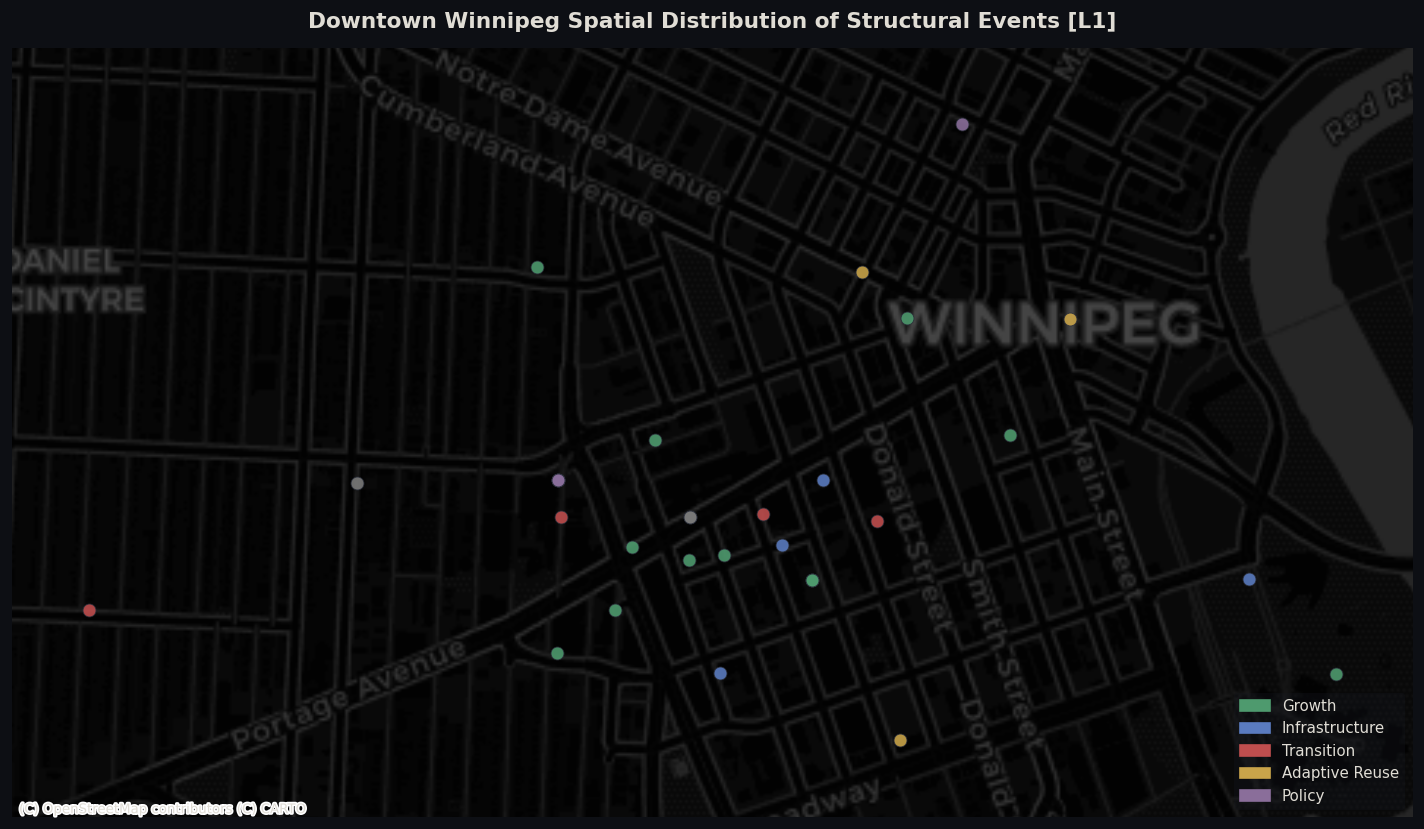

Projects per neighbourhood quadrant (by lon):
east_west        category        
East of -97.145  Adaptive Reuse       3
                 Growth               3
                 Infrastructure       1
                 Policy               1
                 Transition           1
West of -97.145  Growth              11
                 Infrastructure       4
                 Market Indicator     3
                 Policy               2
                 Transition           3


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import contextily as ctx

# Load data
df = pd.read_csv('../data/winnipeg_downtown_projects_2026.csv')

# Clean coordinates
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
df = df.dropna(subset=['lat', 'lon'])

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

# Shift points 100 meters left (west)
# Try -100 first. If still off, test -80 or -120.
gdf['geometry'] = gdf['geometry'].translate(xoff=120, yoff=-20)

# Color map
cat_color_map = {
    'Growth': '#4e9a6e',
    'Infrastructure': '#5a7bbf',
    'Transition': '#bf4e4e',
    'Adaptive Reuse': '#c9a44a',
    'Policy': '#8a6e9a',
}

# Figure
fig, ax = plt.subplots(figsize=(12, 9))
ax.set_facecolor('#0d0f14')

# Plot points
for cat, grp in gdf.groupby('category'):
    grp.plot(
        ax=ax,
        markersize=60,
        color=cat_color_map.get(cat, '#7a7a7a'),
        alpha=0.9,
        edgecolor='#2a2e3a',
        linewidth=0.5,
        label=cat,
        zorder=3
    )

# Set bounds with padding
xmin, ymin, xmax, ymax = gdf.total_bounds
pad_x = 250
pad_y = 250
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.DarkMatter,
    zoom=14
)

# Clean look
ax.set_axis_off()

# Title
ax.set_title(
    'Downtown Winnipeg Spatial Distribution of Structural Events [L1]',
    fontsize=13,
    fontweight='bold',
    pad=12
)

# Legend
handles = [mpatches.Patch(color=v, label=k) for k, v in cat_color_map.items()]
ax.legend(
    handles=handles,
    framealpha=0.3,
    edgecolor='none',
    fontsize=9,
    loc='lower right'
)

plt.tight_layout()
plt.savefig('../visuals/fig_spatial.png', dpi=300, bbox_inches='tight', facecolor='#0d0f14')
plt.show()

# Quadrant summary
df['east_west'] = np.where(df['lon'] > -97.145, 'East of -97.145', 'West of -97.145')
print("Projects per neighbourhood quadrant (by lon):")
print(df.groupby(['east_west', 'category']).size().to_string())

#### Key Findings - Spatial Distribution `[L1]`

- Growth events are concentrated more heavily in the western side of the study area, especially around the Portage Avenue and True North Square corridor
- A secondary cluster is visible around 300 Main and the Forks / Railside area, showing that structural change is not limited to a single downtown block
- Transition events appear more spatially dispersed across the downtown core than Growth events

> **Why this matters:** A visitor standing at Portage and Main may observe an active construction and redevelopment corridor. A visitor in the East Exchange may observe a different downtown entirely. Both readings are valid, but neither captures the full picture. 

## Sources

Full provenance registry with confidence scores, source quality, and linked variables: `downtown_wpg_sources_2026.csv`

Commercial Real Estate Reports

- CBRE Canada. *Canada Office Figures Q4 2024*. January 7, 2025.  
  [https://www.cbre.ca/insights/figures/canada-office-figures-q4-2024](https://www.cbre.ca/insights/figures/canada-office-figures-q4-2024)

- CBRE Canada. *Canada Office Figures Q4 2025*. January 7, 2026.  
  [https://www.cbre.ca/insights/figures/canada-office-figures-q4-2025](https://www.cbre.ca/insights/figures/canada-office-figures-q4-2025)

- CBRE Canada. *Winnipeg Office MarketBeat, Q4 2019*.

- CBRE Canada. *Winnipeg Office MarketBeat, Q4 2022*.

- CBRE Canada. *Winnipeg Office MarketBeat, Q4 2023*.

- CBRE Canada. *Winnipeg Office MarketBeat, Q4 2024*.

- CBRE Canada. *Winnipeg Office MarketBeat, Q4 2025*.

- Cushman & Wakefield. *Winnipeg Office MarketBeat, Q4 2019*.

- Cushman & Wakefield. *Canada Office Marketbeats*. January 7, 2026.

Business Improvement Zone Reports

- Downtown Winnipeg BIZ. *Downtown Snapshot: 2023 End of Year Report*. March 2024.  
  [https://downtownwinnipegbiz.com/wp-content/uploads/2024/03/DowntownSnapshot_2023EndOfYear_WEB_FEB2024.pdf](https://downtownwinnipegbiz.com/wp-content/uploads/2024/03/DowntownSnapshot_2023EndOfYear_WEB_FEB2024.pdf)

- Downtown Winnipeg BIZ. *Downtown Snapshot: Year in Review 2024*. March 2025.  
  [https://downtownwinnipegbiz.com/wp-content/uploads/2025/03/DowntownSnapshot_YearInReview_2024_WEB.pdf](https://downtownwinnipegbiz.com/wp-content/uploads/2025/03/DowntownSnapshot_YearInReview_2024_WEB.pdf)

- Downtown Winnipeg BIZ. *Downtown Snapshot Q1 2024*. April 2024.  
  [https://downtownwinnipegbiz.com/wp-content/uploads/2024/05/DowntownSnapshot_WEB_2024_Q1_APR2024.pdf](https://downtownwinnipegbiz.com/wp-content/uploads/2024/05/DowntownSnapshot_WEB_2024_Q1_APR2024.pdf)

- Downtown Winnipeg BIZ. *Downtown Snapshot Q2 2025*. 2025.  
  [https://downtownwinnipegbiz.com/wp-content/uploads/2025/07/DowntownSnapshot_2025_Q2WEB.pdf](https://downtownwinnipegbiz.com/wp-content/uploads/2025/07/DowntownSnapshot_2025_Q2WEB.pdf)


Government & Institutional Data

- Economic Development Winnipeg. *Real Estate — Office Vacancy Data*. 2016.

- Statistics Canada. *Census Profile, 2021 Census of Population — Winnipeg, City (CSD)*. February 9, 2022.  
  https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/index.cfm?Lang=E

- City of Winnipeg. *Business Licenses Open Data*. Accessed April 2026.  
  https://data.winnipeg.ca/Neighbourhood-Liveability-Property-Standards-Licen/Business-Licenses/d5k3-sfzx

- City of Winnipeg. "Downtown Housing Permits Surge to 15-Year High in 2025." February 25, 2026.  
  https://www.winnipeg.ca/news/2026-02-25-downtown-housing-permits-surge-15-year-high-2025

- Winnipeg Chamber of Commerce. *Downtown Winnipeg Revitalization Policy Position*. 2024.

- Manitoba Métis Federation & Government of Canada. "Manitoba Métis Federation and Government of Canada Announce Investment of Over $1.45 Million for the Red River Métis." July 4, 2023.  
  https://www.mmf.mb.ca/news/manitoba-metis-federation-and-government-of-canada-announce-investment-of-over-145-million-for-the-red-river-metis

- Manitoba Métis Federation. "Red River Métis 'Our Grandmothers' Collection Finds Its Way Home." June 27, 2025.  
  https://www.mmf.mb.ca/news/red-river-metis-our-grandmothers-collection-finds-its-way-home

- BMO Financial Group. "BMO and Manitoba Métis Federation Working Together to Transform Historic Portage and Main Building into Future Home of the Métis Nation Heritage Centre." May 11, 2020.  
  https://newsroom.bmo.com/2020-05-11-BMO-and-Manitoba-Metis-Federation-Working-Together-to-Transform-Historic-Portage-and-Main-Building-into-Future-Home-of-the-Metis-Nation-Heritage-Centre

- Number TEN Architectural Group. *MMF National Heritage Centre*.  
  https://www.numberten.com/project/mmf-national-heritage-centre/

- Manitoba Supports Railside Development Project at The Forks. *Government of Manitoba*. December 18, 2019  
  https://news.gov.mb.ca/news/?archive=&item=46557#:~:text=The%20Manitoba%20government%20will%20invest,announced%20today%20at%20The%20Forks.

National Office Vacancy — News Coverage

- Woelk, Daisy. "Why Canada's downtown office vacancy rate hit a record high to end 2023." *Global News*. January 10, 2024.  
  https://globalnews.ca/news/10216439/why-canada-downtown-office-vacancy-record-high-2023/

- Bickis, Ian. "Office vacancy rate dips as return-to-office shift picks up: CBRE report." *The Canadian Press / BNN Bloomberg*. January 7, 2026.  
  https://www.bnnbloomberg.ca/business/2026/01/07/office-vacancy-rate-dips-as-return-to-office-shift-picks-up-cbre-report/

- "Office vacancy rates continue to drop, but the recovery is uneven." *The Globe and Mail*. January 7, 2026.  
  https://www.theglobeandmail.com/business/article-office-vacancy-rates-drop-recovery/


Downtown Winnipeg — CBC Manitoba Reporting

- "Historic Portage and Main BMO building to become future home of Métis Nation Heritage Centre." *CBC News*. May 12, 2020.  
  https://www.cbc.ca/news/canada/manitoba/mmf-to-buy-bmo-building-in-winnipeg-1.5565613

- MacLean, Cameron. "Grant program aims to reverse trend of disappearing businesses in downtown Winnipeg." *CBC News*. July 18, 2022.  
  https://www.cbc.ca/news/canada/manitoba/downtown-winnipeg-building-business-program-1.6524428

- Bernhardt, Darren. "On the way to Wehwehneh: What it takes to transform downtown Winnipeg's former Bay." *CBC News*. April 17, 2023.  
  https://www.cbc.ca/news/canada/manitoba/wehwehneh-winnipeg-former-bay-redevelopment-1.6807000

- Kives, Bartley. "Southern Chiefs' Organization praises potential True North purchase of Portage Place." *CBC News*. April 18, 2023.  
  https://www.cbc.ca/news/canada/manitoba/bay-portage-place-sco-true-north-1.6813542

- Kives, Bartley. "True North redevelopment plan for Portage Place met with cautious optimism." *CBC News*. May 12, 2023.  
  https://www.cbc.ca/news/canada/manitoba/portage-place-true-north-reaction-1.6841551

- Kives, Bartley. "Plans to redevelop Portage Place, former Bay building need to proceed 'essentially in lockstep': True North." *CBC News*. December 1, 2023.  
  https://www.cbc.ca/news/canada/manitoba/true-north-portage-place-redevelopment-1.7045553

- Kives, Bartley. "True North, Southern Chiefs' Organization sign partnership they say will be catalyst to revitalize downtown Winnipeg." *CBC News*. December 12, 2023.  
  https://www.cbc.ca/news/canada/manitoba/redevelop-plans-portage-place-bay-true-north-sco-winnipeg-1.7056507

- Bernhardt, Darren. "'We are bouncing back,' but Winnipeg's downtown recovery still a work in progress, report suggests." *CBC News*. March 6, 2024.  
  https://www.cbc.ca/news/canada/manitoba/downtown-winnipeg-snapshot-report-biz-1.7135193

- Kives, Bartley. "True North, Southern Chiefs' Organization agree to build 15-storey residential tower at Portage Place together." *CBC News*. April 5, 2024.  
  https://www.cbc.ca/news/canada/manitoba/portage-place-wab-kinew-1.7164313

- Bernhardt, Darren. "Wehwehneh Bahgahkinahgohn transformation of former Winnipeg Bay building gets another $31M from feds." *CBC News*. May 24, 2024.  
  https://www.cbc.ca/news/canada/manitoba/wehwehneh-bahgahkinahgohn-thebay-winnipeg-transformation-1.7213774

- Bernhardt, Darren. "Southern Chiefs' Organization to adjust cost, scope of downtown Winnipeg Bay redevelopment." *CBC News*. March 19, 2025.  
  https://www.cbc.ca/news/canada/manitoba/wehwehneh-winnipeg-bay-building-update-1.7487182

- "Hundreds of residential units coming as construction starts on 1st housing project at The Forks." *CBC News*. January 15, 2026.  
  https://www.cbc.ca/news/canada/manitoba/the-forks-railside-housing-development-construction-starts-9.7047511

- "A look at 9 significant construction projects underway in Winnipeg this year." *CBC News*. January 17, 2026.  
  https://www.cbc.ca/news/canada/manitoba/major-winnipeg-projects-2026-9.7047651

- "Winnipeg's St. Charles Hotel slated to become 11-storey residential tower, facade will remain." *CBC News*. January 27, 2026.  
  https://www.cbc.ca/news/canada/manitoba/centreventure-winnipeg-downtown-housing-heritage-buildings-9.7063117

- Scott, Lauren. "Portage Place atrium coming down as redevelopment project aims for 2028 completion." *CBC News*. January 27, 2026.  
  https://www.cbc.ca/news/canada/manitoba/portage-place-construction-9.7063848


Other News Coverage

- Woelk, Daisy. "Downtown Winnipeg 'on the right track,' according to 2023 snapshot." *Global News*. March 6, 2024.  
  https://globalnews.ca/news/10339226/downtown-winnipeg-snapshot-2023/

- Caulfield, Peter. "First phase of Winnipeg Railside development to break ground." *Journal of Commerce / ConstructConnect*. May 3, 2024.  
  https://canada.constructconnect.com/joc/news/projects/2024/05/first-phase-of-winnipeg-railside-development-to-break-ground

- "Hotel being built at True North Square is years behind schedule." *CTV News Winnipeg*. November 22, 2024.  
  https://www.ctvnews.ca/winnipeg/article/hotel-being-built-at-true-north-square-is-years-behind-schedule/

- Caulfield, Peter. "At last: Winnipeg's Portage Place redevelopment gets official go-ahead." *Journal of Commerce / ConstructConnect*. December 19, 2024.  
  https://canada.constructconnect.com/joc/news/projects/2024/12/at-last-winnipegs-portage-place-redevelopment-gets-official-go-ahead

- Bernacki, Joseph. "Downtown Winnipeg BIZ 2024 report filled with optimism for neighbourhood." *CTV News Winnipeg*. April 1, 2025.  
  https://www.ctvnews.ca/winnipeg/article/downtown-winnipeg-biz-snapshot-filled-with-optimism-for-core/

- Bernacki, Joseph. "From heritage buildings to homes: How more housing could be coming to downtown Winnipeg." *CTV News Winnipeg*.  
  https://www.ctvnews.ca/winnipeg/article/from-heritage-buildings-to-homes-how-more-housing-could-be-coming-to-downtown-winnipeg/

- "Nearly 300 New Housing Units Planned for Downtown Winnipeg Redevelopment." *ChrisD.ca*. January 27, 2026.  
  https://www.chrisd.ca/2026/01/27/downtown-winnipeg-housing-units-redevelopment-centreventure/


Reference

- "True North Square." *Wikipedia*.  
  https://en.wikipedia.org/wiki/True_North_Square
